In [ ]:
# download midis_v1.2.zip from https://drive.google.com/drive/folders/1Stz3CAvMoplo79LR5I3onMWRelCugBYS
# put the midis folder into data/raw

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from preprocessing import preprocess_dataset, load_pickle
from markov import (
    train_event_unigram,
    train_event_bigram,
    train_event_second_order,
    generate_event_unigram,
    generate_event_bigram,
    generate_event_second_order
)
from midi_output import save_event_midi

random.seed(0)
np.random.seed(0)

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "midis"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw dir:", RAW_DIR)
print("Raw dir exists:", RAW_DIR.exists())
print("Processed dir:", PROCESSED_DIR)
print("Output dir:", OUTPUT_DIR)

Project root: c:\CSE153-Assignment-2-Task-1
Raw dir: c:\CSE153-Assignment-2-Task-1\data\raw\midis
Raw dir exists: True
Processed dir: c:\CSE153-Assignment-2-Task-1\data\processed
Output dir: c:\CSE153-Assignment-2-Task-1\outputs


In [2]:
# ONLY NEED TO RUN ONCE PER SESSION

train_songs, test_songs, failed = preprocess_dataset(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    max_files=500,
    min_events=20,
    max_chord_size=8,
    test_size=0.2,
    seed=0
)

MIDI files found: 10841
Processed 100/500 files | usable: 100 | failed: 0
Processed 200/500 files | usable: 200 | failed: 0
Processed 300/500 files | usable: 299 | failed: 0
Processed 400/500 files | usable: 399 | failed: 0
Processed 500/500 files | usable: 499 | failed: 0
Usable songs: 499
Train songs: 399
Test songs: 100
Failed files: 0


In [3]:
train_songs = load_pickle(PROCESSED_DIR / "train_songs.pkl")
test_songs = load_pickle(PROCESSED_DIR / "test_songs.pkl")
failed = load_pickle(PROCESSED_DIR / "failed_files.pkl")

print("Train songs:", len(train_songs))
print("Test songs:", len(test_songs))
print("Failed files:", len(failed))

Train songs: 399
Test songs: 100
Failed files: 0


In [4]:
example = train_songs[0]

print("Example path:", example["path"])
print("Number of events:", example["num_events"])
print("Number of notes:", example["num_notes"])
print("First 5 events:")

for event in example["events"][:5]:
    print(event)

Example path: c:\CSE153-Assignment-2-Task-1\data\raw\midis\Ascher, Joseph, La perle du nord, hdAV8nPxnw4.mid
Number of events: 1153
Number of notes: 3091
First 5 events:
{'gap': 0, 'pitches': (55, 58, 63, 67, 70, 75), 'durations': (120, 120, 120, 120, 120, 120), 'velocities': (96, 102, 97, 90, 97, 91)}
{'gap': 120, 'pitches': (55, 58, 63, 67, 70, 75), 'durations': (1200, 1920, 1200, 1200, 1200, 1200), 'velocities': (83, 97, 86, 83, 104, 97)}
{'gap': 1200, 'pitches': (55, 59, 59, 63, 63, 67, 71, 71), 'durations': (720, 120, 720, 120, 600, 840, 120, 720), 'velocities': (97, 101, 99, 97, 81, 89, 95, 101)}
{'gap': 600, 'pitches': (56, 60, 63, 68, 72), 'durations': (120, 120, 120, 120, 120), 'velocities': (101, 104, 94, 106, 95)}
{'gap': 120, 'pitches': (56, 60, 63, 68, 72), 'durations': (120, 120, 120, 120, 480), 'velocities': (98, 100, 84, 107, 102)}


In [5]:
all_events = [
    event
    for song in train_songs
    for event in song["events"]
]

all_pitches = [
    pitch
    for event in all_events
    for pitch in event["pitches"]
]

all_durations = [
    duration
    for event in all_events
    for duration in event["durations"]
]

all_gaps = [
    event["gap"]
    for event in all_events
]

song_event_lengths = [
    song["num_events"]
    for song in train_songs
]

chord_sizes = [
    len(event["pitches"])
    for event in all_events
]

event_intervals = []

for song in train_songs:
    melody_like_pitches = [
        max(event["pitches"])
        for event in song["events"]
        if len(event["pitches"]) > 0
    ]

    event_intervals.extend([
        b - a
        for a, b in zip(melody_like_pitches[:-1], melody_like_pitches[1:])
    ])

summary = pd.DataFrame({
    "num_train_songs": [len(train_songs)],
    "num_test_songs": [len(test_songs)],
    "num_train_events": [len(all_events)],
    "num_train_notes": [len(all_pitches)],
    "min_pitch": [min(all_pitches)],
    "max_pitch": [max(all_pitches)],
    "avg_events_per_song": [np.mean(song_event_lengths)],
    "median_events_per_song": [np.median(song_event_lengths)],
    "avg_chord_size": [np.mean(chord_sizes)],
    "max_chord_size": [max(chord_sizes)],
    "num_failed_files": [len(failed)]
})

summary

,num_train_songs,num_test_songs,num_train_events,num_train_notes,min_pitch,max_pitch,avg_events_per_song,median_events_per_song,avg_chord_size,max_chord_size,num_failed_files
0,399,100,627312,1500523,22,105,1572.210526,851.0,2.391988,8,0


##### START VIS!
Instead of flattening piano music into a one-note-at-a-time sequence, I represent each MIDI file as a sequence of onset events. Each onset event contains the time gap from the previous event, the pitches that start together, and the duration of each pitch. This representation is better suited to piano music because it preserves simultaneous notes and allows the model to generate chord-like textures directly.

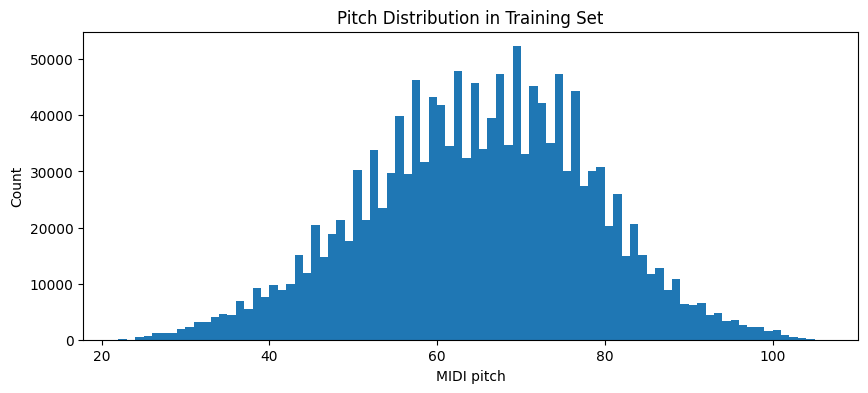

In [6]:
plt.figure(figsize=(10, 4))
plt.hist(
    all_pitches,
    bins=range(min(all_pitches), max(all_pitches) + 2)
)
plt.xlabel("MIDI pitch")
plt.ylabel("Count")
plt.title("Pitch Distribution in Training Set")
plt.show()

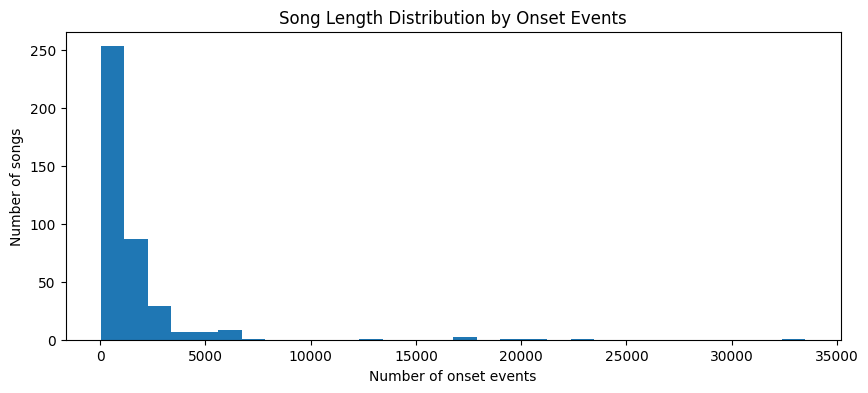

In [7]:
plt.figure(figsize=(10, 4))
plt.hist(song_event_lengths, bins=30)
plt.xlabel("Number of onset events")
plt.ylabel("Number of songs")
plt.title("Song Length Distribution by Onset Events")
plt.show()

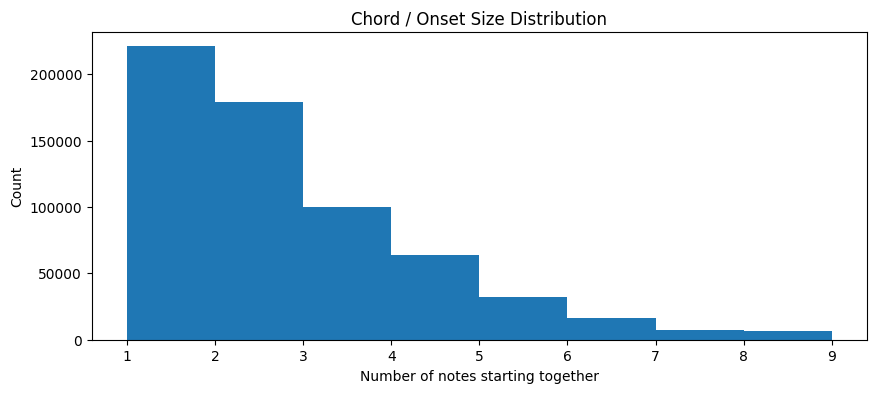

In [8]:
plt.figure(figsize=(10, 4))
plt.hist(chord_sizes, bins=range(1, max(chord_sizes) + 2))
plt.xlabel("Number of notes starting together")
plt.ylabel("Count")
plt.title("Chord / Onset Size Distribution")
plt.show()

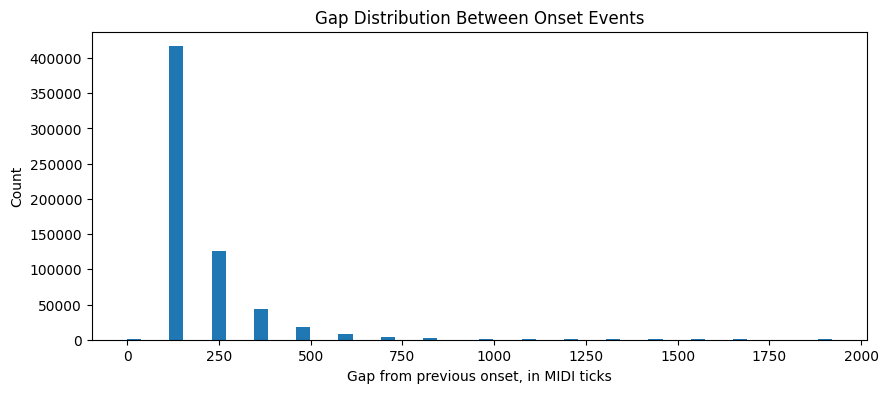

In [9]:
plt.figure(figsize=(10, 4))
plt.hist(all_gaps, bins=50)
plt.xlabel("Gap from previous onset, in MIDI ticks")
plt.ylabel("Count")
plt.title("Gap Distribution Between Onset Events")
plt.show()

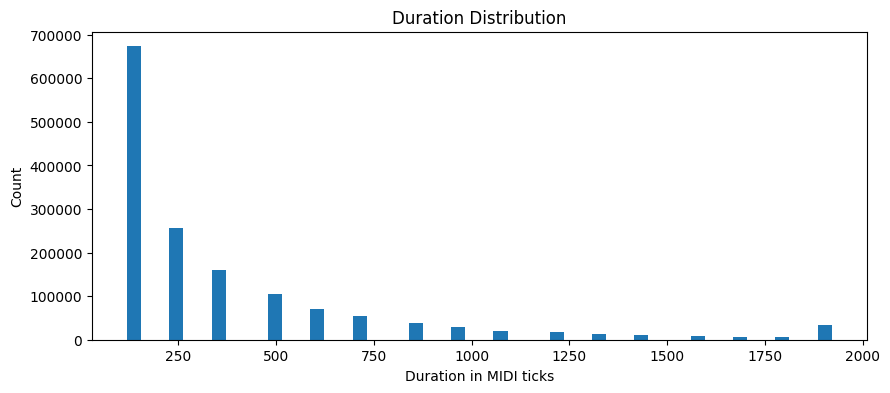

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(all_durations, bins=50)
plt.xlabel("Duration in MIDI ticks")
plt.ylabel("Count")
plt.title("Duration Distribution")
plt.show()

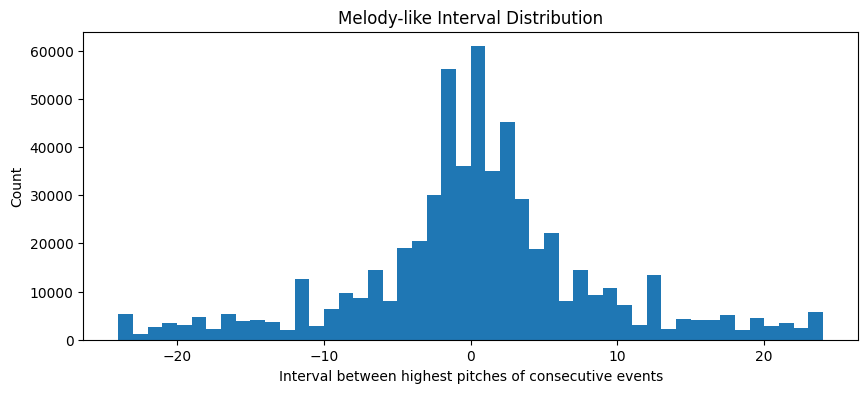

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(event_intervals, bins=range(-24, 25))
plt.xlabel("Interval between highest pitches of consecutive events")
plt.ylabel("Count")
plt.title("Melody-like Interval Distribution")
plt.show()

##### ML STUFF!

This task is symbolic unconditioned generation. The model learns a distribution over onset events from the training MIDI files and samples new event sequences from that distribution.

I compare three models:

1. An event unigram baseline, which estimates p(event).
2. An event bigram Markov model, which estimates p(next event | previous event).
3. An event second-order Markov model, which estimates p(next event | previous two events).

Each event can contain multiple notes, so the model can generate chords and layered piano textures directly instead of relying on manual chord postprocessing.

In [ ]:
event_unigram = train_event_unigram(train_songs)
event_bigram = train_event_bigram(train_songs)
event_second_order = train_event_second_order(train_songs)

model_summary = pd.DataFrame({
    "model_component": [
        "Event unigram model",
        "Event bigram model",
        "Event second-order model"
    ],
    "num_states": [
        len(event_unigram),
        len(event_bigram),
        len(event_second_order)
    ]
})

model_summary

,model_component,num_states
0,Event unigram model,251488
1,Event bigram model,251241
2,Event second-order model,535581


In [ ]:
N_EVENTS = 300
TEMPERATURE = 0.8

unigram_events = generate_event_unigram(
    event_unigram,
    n=N_EVENTS,
    temperature=TEMPERATURE
)

bigram_events = generate_event_bigram(
    event_bigram,
    event_unigram,
    n=N_EVENTS,
    temperature=TEMPERATURE
)

second_order_events = generate_event_second_order(
    event_second_order,
    event_bigram,
    event_unigram,
    n=N_EVENTS,
    temperature=TEMPERATURE
)

print("Generated events:", len(second_order_events))
print("First 5 generated events:")

for event in second_order_events[:5]:
    print(event)

Generated events: 300
First 5 generated events:
{'gap': 120, 'pitches': (64,), 'durations': (480,)}
{'gap': 120, 'pitches': (67,), 'durations': (480,)}
{'gap': 120, 'pitches': (79, 82), 'durations': (360, 240)}
{'gap': 120, 'pitches': (85,), 'durations': (120,)}
{'gap': 120, 'pitches': (88,), 'durations': (240,)}


In [ ]:
save_event_midi(
    unigram_events,
    OUTPUT_DIR / "event_unigram_sample.mid"
)

save_event_midi(
    bigram_events,
    OUTPUT_DIR / "event_bigram_sample.mid"
)

save_event_midi(
    second_order_events,
    OUTPUT_DIR / "symbolic_unconditioned.mid"
)

print("Saved generated MIDI files:")
print(OUTPUT_DIR / "event_unigram_sample.mid")
print(OUTPUT_DIR / "event_bigram_sample.mid")
print(OUTPUT_DIR / "symbolic_unconditioned.mid")

Saved generated MIDI files:
c:\CSE153-Assignment-2-Task-1\outputs\event_unigram_sample.mid
c:\CSE153-Assignment-2-Task-1\outputs\event_bigram_sample.mid
c:\CSE153-Assignment-2-Task-1\outputs\symbolic_unconditioned.mid


# Neural Models: LSTM vs. From-Scratch Transformer

The Markov models in the previous section counts the whole events of gap, pitches, and durations. The following two models, both of which are neural models, aim to learn the structure of the music instead of just memorizing it. 

## The problem: vocabulary explosion

The issue is: a full event has too much information to fit into a single token, which is why Markov is just memorization, and generates predictions based on those memorizations. Even the second-order Markov that is being used here requires a back-off mechanism, back to bigram or unigram. 

## The solution: event decomposition

Instead of one giant token per event, we **decompose** every event into a short, ordered sequence of sub-tokens: ```GAP_g  →  PITCH_p1  DUR_d1  →  PITCH_p2  DUR_d2  →  …  →  EOE ```

where `EOE` marks the end of an event. Because gaps and durations are quantised to a coarse grid in preprocessing and pitches live on the 88-key range, this collapses the vocabulary from ~250k atomic events down to just **125 sub-tokens**, each one now seen tens of thousands of times. The network can share statistical strength *across* events: it learns that nearby pitches behave similarly and that certain gap/duration patterns recur, instead of treating every chord as an unrelated symbol.

## Roadmap for this section

1. **Tokeniser** - flatten the corpus into one ~4.3M sub-token stream.
2. **LSTM baseline** - a recurrent model to confirm the pipeline learns and to anchor the comparison.
3. **Transformer (main model)** - a from-scratch decoder-only network with a causal mask.
4. **Evaluation** - held-out per-event perplexity (objective) **and** musical statistics (subjective proxy), because, as we will see, the two do not agree.

In [ ]:
import torch
from neural import (
    EventTokenizer, EventLSTM, LSTMConfig, EventTransformer, TransformerConfig,
    train_model, generate, count_params,
)
from evaluation import (
    neural_event_perplexity, markov_event_perplexity,
    musical_report, reference_stats, pitch_class_histogram, kl_divergence,
    aggregate_reports,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

tokenizer = EventTokenizer()
print("Sub-token vocabulary size:", tokenizer.vocab_size)

# Flatten every song into one long id stream (nanoGPT style).
train_stream = tokenizer.encode_songs(train_songs)
val_stream   = tokenizer.encode_songs(test_songs)
print("Train sub-tokens:", len(train_stream), "| Val sub-tokens:", len(val_stream))

Using device: cuda
Sub-token vocabulary size: 125
Train sub-tokens: 4256468 | Val sub-tokens: 903616


## The recurrent baseline: `EventLSTM`

We begin with a 2-layer LSTM. It does 3 things: confirming the tokeniser and training loop work end to end, giving the Transformer a fair recurrent competitor, and setting a reference perplexity to beat.

Architecturally, the LSTM compresses all preceding history into a fixed-size hidden state. That is cheap and fast, but it is also the model's limitation: long-range musical structure may not survive being squeezed through that bottleneck at every step. 

We expect this to cap how much global coherence it can hold onto, and the comparison below tests exactly that.

In [ ]:
lstm = EventLSTM(LSTMConfig(
    vocab_size=tokenizer.vocab_size,
    embed_dim=256, hidden_dim=512, num_layers=2, dropout=0.3,
))
print("LSTM parameters:", f"{count_params(lstm):,}")

lstm_history = train_model(
    lstm, train_stream, val_stream, tokenizer,
    block_size=256, epochs=20, batch_size=64, lr=3e-3,
    device=DEVICE, log_every=2,
)

LSTM parameters: 3,774,333
epoch   2 | train loss 1.7241 | val loss 1.6023 | val ppl/token 4.96
epoch   4 | train loss 1.5946 | val loss 1.5276 | val ppl/token 4.61
epoch   6 | train loss 1.5385 | val loss 1.4954 | val ppl/token 4.46
epoch   8 | train loss 1.5010 | val loss 1.4814 | val ppl/token 4.40
epoch  10 | train loss 1.4726 | val loss 1.4693 | val ppl/token 4.35
epoch  12 | train loss 1.4500 | val loss 1.4644 | val ppl/token 4.33
epoch  14 | train loss 1.4321 | val loss 1.4582 | val ppl/token 4.30
epoch  16 | train loss 1.4160 | val loss 1.4578 | val ppl/token 4.30
epoch  18 | train loss 1.4020 | val loss 1.4570 | val ppl/token 4.29
epoch  20 | train loss 1.3903 | val loss 1.4573 | val ppl/token 4.29
Restored best checkpoint from epoch 19 (val loss 1.4570, val ppl/token 4.29)


## The main model: a from-scratch decoder-only Transformer

Our primary model is a GPT-style decoder built from scratch: token embedding + learned positional encodings → a stack of **pre-norm blocks** (causal multi-head self-attention + MLP) → a final layer-norm → a **weight-tied** output head. The defining component is the **causal self-attention mask**: position *t* may attend to every position *≤ t* and never to the future, which is what makes the model a valid left-to-right generator.

The hypothesis is that, since the Transformer has **direct access to the whole context window** (here 512 sub-tokens) rather than a compressed summary, so it should capture longer-range dependencies. The configuration below is ~10.9M parameters. Whether that extra capacity actually pays off on a corpus this size is the question the evaluation answers, and the answer is not a simple yes.

In [ ]:
BLOCK_SIZE = 512

transformer = EventTransformer(TransformerConfig(
    vocab_size=tokenizer.vocab_size,
    block_size=BLOCK_SIZE,
    n_layer=6, n_head=6, n_embd=384, dropout=0.1,
))
print("Transformer parameters:", f"{count_params(transformer):,}")

tf_history = train_model(
    transformer, train_stream, val_stream, tokenizer,
    block_size=BLOCK_SIZE, epochs=30, batch_size=32, lr=3e-4,
    device=DEVICE, log_every=2,
)

Transformer parameters: 10,892,160
epoch   2 | train loss 1.9287 | val loss 1.7622 | val ppl/token 5.83
epoch   4 | train loss 1.7173 | val loss 1.6070 | val ppl/token 4.99
epoch   6 | train loss 1.6154 | val loss 1.5332 | val ppl/token 4.63
epoch   8 | train loss 1.5531 | val loss 1.4873 | val ppl/token 4.43
epoch  10 | train loss 1.5037 | val loss 1.4556 | val ppl/token 4.29
epoch  12 | train loss 1.4610 | val loss 1.4325 | val ppl/token 4.19
epoch  14 | train loss 1.4214 | val loss 1.4211 | val ppl/token 4.14
epoch  16 | train loss 1.3854 | val loss 1.4120 | val ppl/token 4.10
epoch  18 | train loss 1.3505 | val loss 1.4102 | val ppl/token 4.10
epoch  20 | train loss 1.3167 | val loss 1.4146 | val ppl/token 4.11
epoch  22 | train loss 1.2838 | val loss 1.4171 | val ppl/token 4.13
epoch  24 | train loss 1.2519 | val loss 1.4330 | val ppl/token 4.19
epoch  26 | train loss 1.2208 | val loss 1.4464 | val ppl/token 4.25
epoch  28 | train loss 1.1914 | val loss 1.4658 | val ppl/token 4.33

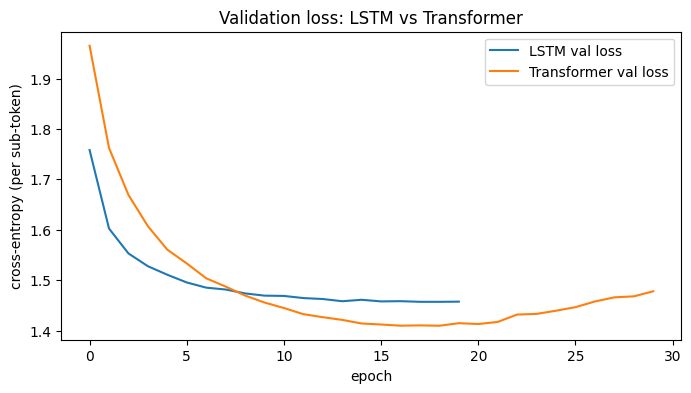

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(lstm_history["val_loss"], label="LSTM val loss")
plt.plot(tf_history["val_loss"],   label="Transformer val loss")
plt.xlabel("epoch"); plt.ylabel("cross-entropy (per sub-token)")
plt.title("Validation loss: LSTM vs Transformer")
plt.legend(); plt.show()

### Discussion: LSTM and Transformer are close!

The validation curve above is **U-shaped** for the Transformer: it bottoms out around epoch ~18–19 and then climbs as the model begins to memorise the training stream. The lower-capacity LSTM flattens out instead of turning up. This indicates the model is running short of data. Because of it, `train_model` keeps the **best-validation checkpoint** rather than the final, over-fit weights.



## Generation: autoregressive sampling

We generate one sub-token at a time, feed each choice back in as context, and finally decode the sub-token stream back into events. Two knobs shape the output:

- **Temperature** scales the logits: lower → more conservative and repetitive, higher → more diverse and risky.
- **Top-k / top-p (nucleus)** truncation removes the long tail of implausible sub-tokens before sampling, trading diversity for coherence.

To keep the comparison fair we use **identical decode settings for both neural models** (so any difference reflects the model, not the sampler) and draw **5 samples per model**, so the statistics below are reported as mean ± std rather than just luck.

In [ ]:
from midi_output import save_event_midi
from markov import generate_event_second_order
import random, numpy as np

# Identical decode settings for BOTH neural models so the comparison reflects
# the model and not the sampler. We also draw several samples per model so the
# musical statistics below are reported as mean +/- std rather than one lucky
# (or unlucky) draw, and we match sample lengths across model families.
N_SAMPLES  = 5
DECODE     = dict(temperature=0.95, top_p=0.95)
MAX_TOKENS = 1200          # sub-tokens -> ~125 events for the neural models
MARKOV_N   = 130           # chosen so the Markov sample length is comparable

def gen_neural(model):
    return [generate(model, tokenizer, max_tokens=MAX_TOKENS,
                     device=DEVICE, seed=s, **DECODE)
            for s in range(N_SAMPLES)]

def gen_markov():
    out = []
    for s in range(N_SAMPLES):
        random.seed(s); np.random.seed(s)        # reproducible Markov draws
        out.append(generate_event_second_order(
            event_second_order, event_bigram, event_unigram,
            n=MARKOV_N, temperature=0.8))
    return out

tf_samples     = gen_neural(transformer)
lstm_samples   = gen_neural(lstm)
markov_samples = gen_markov()

# The first transformer sample is the graded deliverable.
tf_events, lstm_events, markov_events = tf_samples[0], lstm_samples[0], markov_samples[0]
save_event_midi(tf_events,     OUTPUT_DIR / "symbolic_unconditioned_transformer.mid")
save_event_midi(lstm_events,   OUTPUT_DIR / "lstm_sample.mid")
save_event_midi(markov_events, OUTPUT_DIR / "markov_sample.mid")

print("Saved symbolic_unconditioned.mid (transformer), lstm_sample.mid, markov_sample.mid")
print("events per transformer sample:", [len(s) for s in tf_samples])
print("events per lstm sample:       ", [len(s) for s in lstm_samples])
print("events per markov sample:     ", [len(s) for s in markov_samples])

Saved symbolic_unconditioned.mid (transformer), lstm_sample.mid, markov_sample.mid
events per transformer sample: [138, 162, 143, 154, 181]
events per lstm sample:        [187, 185, 222, 184, 148]
events per markov sample:      [130, 130, 130, 130, 130]


# Evaluation

How do we know whether generated music is "good"? We evaluate along two axes that, as it turns out, **do not agree**.

**1. Objective: held-out per-event perplexity.** Because the neural models predict *sub-tokens* while the Markov models predict whole *events*, raw per-token perplexity is not comparable across families (finer tokenisation inflates token counts). We therefore score every model on the same unit: the negative log-likelihood of the next **event** given history (for the neural models, the summed log-probs of that event's sub-tokens). Lower is better.

**2. Subjective proxy: musical statistics.** Perplexity rewards predicting the data, not musical plausibility. So we also compare distributional properties of generated vs. real music: pitch-class distribution (KL divergence), polyphony, note density, repetition structure, and key consistency. A good model should *match the real-data statistics*, not merely minimise perplexity.

TLDR: the neural models **win on perplexity but lose on several musical statistics**. The next two cells show this directly.

In [ ]:
import pandas as pd

# make sure models and scoring are on the same device
lstm = lstm.to("cpu")
transformer = transformer.to("cpu")

# We compare on per-SUB-TOKEN perplexity (the common unit across both model
# families). Per-EVENT perplexity is astronomically large (an event is many
# sub-tokens) and not interpretable, so we report per-event NLL in nats instead.
def row(name, r):
    return {"model": name,
            "ppl_per_token": r["perplexity_per_token"],
            "nll_per_event_nats": r["nll_per_event"]}

rows = [
    row("Markov unigram",   markov_event_perplexity(test_songs, event_unigram, tokenizer=tokenizer)),
    row("Markov bigram",    markov_event_perplexity(test_songs, event_unigram, event_bigram, tokenizer=tokenizer)),
    row("Markov 2nd-order", markov_event_perplexity(test_songs, event_unigram, event_bigram, event_second_order, tokenizer=tokenizer)),
    row("LSTM",             neural_event_perplexity(lstm, tokenizer, test_songs, device="cpu")),
    row("Transformer",      neural_event_perplexity(transformer, tokenizer, test_songs, device="cpu")),
]
ppl_df = pd.DataFrame(rows).sort_values("ppl_per_token").reset_index(drop=True)
ppl_df

,model,ppl_per_token,nll_per_event_nats
0,Transformer,4.000007,9.611091
1,LSTM,4.148743,9.864207
2,Markov 2nd-order,4.489727,10.411815
3,Markov bigram,4.545164,10.496895
4,Markov unigram,4.896694,11.013375


In [ ]:
# Musical statistics: each model's generated samples vs. the real training data.
# Model rows are mean +/- std over the N_SAMPLES draws from the cell above.
ref_events = [e for s in train_songs for e in s["events"]]

stats_rows = {
    "Real (train)": reference_stats(train_songs),
    "Markov 2nd":   aggregate_reports(markov_samples, ref_events),
    "LSTM":         aggregate_reports(lstm_samples,   ref_events),
    "Transformer":  aggregate_reports(tf_samples,     ref_events),
}
stats_df = pd.DataFrame(stats_rows).T
stats_df

,avg_polyphony,note_density,repetition_rate,distinct_event_ratio,key_consistency,pc_kl_vs_reference,num_events,num_notes,pitch_range
Real (train),2.392,1.4396,0.007,0.401,0.786,0.0,627312,1500523,"(22, 105)"
Markov 2nd,2.595 +/- 0.617,2.093 +/- 0.544,0.000 +/- 0.000,0.932 +/- 0.039,0.662 +/- 0.094,0.229 +/- 0.100,130,337,"(25, 104)"
LSTM,2.293 +/- 0.433,1.990 +/- 0.310,0.018 +/- 0.013,0.643 +/- 0.088,0.839 +/- 0.080,0.526 +/- 0.070,185,414,"(36, 86)"
Transformer,2.876 +/- 0.358,2.734 +/- 0.267,0.114 +/- 0.110,0.516 +/- 0.267,0.756 +/- 0.168,1.706 +/- 0.731,155,442,"(24, 92)"


### Discussion: perplexity is not musical plausibility

This is the central tension of the task, and our two tables disagree on who "wins".

**The neural models win the objective.** On held-out per-event perplexity the Transformer (~4.00) and LSTM (~4.14) clearly beat the best Markov model (~4.49). By the metric the models actually optimise, learning beats counting.

**But the Markov model wins the pitch-class distribution.** Its pitch-class histogram is far closer to real music: `pc_kl_vs_reference` ≈ **0.23 bits** versus ≈ 0.59 (LSTM) and ≈ 1.71 (Transformer). Since the Markov model copies short verbatim n-grams from the corpus, it can reproduce this local statistic.

**The neural models win other musical statistics.** They imply a single key more coherently (`key_consistency` ≈ 0.76–0.78 vs Markov's 0.66, against ≈ 0.79 for real music), and they reuse motifs more like real music: the Transformer's `distinct_event_ratio` ≈ 0.52 is closest to the real 0.40, whereas the Markov model over-diversifies (≈ 0.93, it almost never repeats an event). The LSTM also best matches real **texture**: its polyphony ≈ 2.4 and note density ≈ 1.7 are closest to the real ≈ 2.4 / ≈ 1.4, whereas the Markov (≈ 2.6 / ≈ 2.1) and especially the Transformer (≈ 2.9 / ≈ 2.7) both run denser.

| Property | Best match to real | Why |
|---|---|---|
| Held-out perplexity | **Neural (Transformer)** | learns grammar, doesn't just count |
| Pitch-class distribution (KL) | **Markov** | copies local n-grams verbatim |
| Texture (density / polyphony) | **LSTM** | best matches real density; Markov & Transformer run denser |
| Key consistency | **Neural** | captures longer-range tonal context |
| Motif reuse (distinct-event ratio) | **Neural (Transformer)** | Markov over-diversifies |

The lesson: **minimising held-out NLL rewards predicting the next sub-token well, which is not the same as reproducing the global distributional properties of real music.** A model can be the best next-token predictor and still drift in density, repetition, and pitch-class profile. This is precisely why we report musical statistics alongside perplexity, and why the listening comparison, rather than any single number, is the real arbiter of "beautiful music".

## Pitch-class distribution: generated vs. real

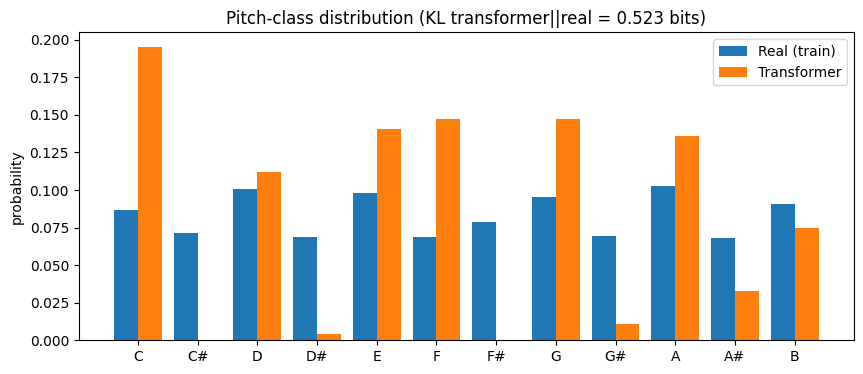

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pc_names = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
ref_pc = pitch_class_histogram(ref_events)
tf_pc  = pitch_class_histogram(tf_events)

x = np.arange(12); w = 0.4
plt.figure(figsize=(10,4))
plt.bar(x - w/2, ref_pc, width=w, label="Real (train)")
plt.bar(x + w/2, tf_pc,  width=w, label="Transformer")
plt.xticks(x, pc_names); plt.ylabel("probability")
plt.title(f"Pitch-class distribution (KL transformer||real = "
          f"{kl_divergence(tf_pc, ref_pc):.3f} bits)")
plt.legend(); plt.show()

A pitch-class histogram counts how often each of the 12 notes (C, C#, D, ...) shows up, ignoring octave. It's a quick way to check whether a model picked up on tonality. Real music in a key leans heavily on some pitch classes and avoids others, so a model that learned the key structure should produce a similarly uneven distribution, close to the real one, which shows up as a low KL divergence. A model that didn't learn it spreads notes out more evenly and lands further from the real shape. The plot below puts the Transformer's distribution next to the real data and shows the KL in the title, so the number from the table above becomes something you can actually see.

One caveat about the number in the plot. The KL in the title comes from a single generated sample (tf_samples[0]), but the evaluation table averages over 5 samples and reports 1.71 ± 0.73 bits. That large standard deviation matters: the Transformer's pitch-class profile shifts a lot from one sample to the next, and this particular sample happens to be a good one (~0.52). So the table's mean and spread is the number to trust, not this single plot.

## Interpretability: visualising self-attention

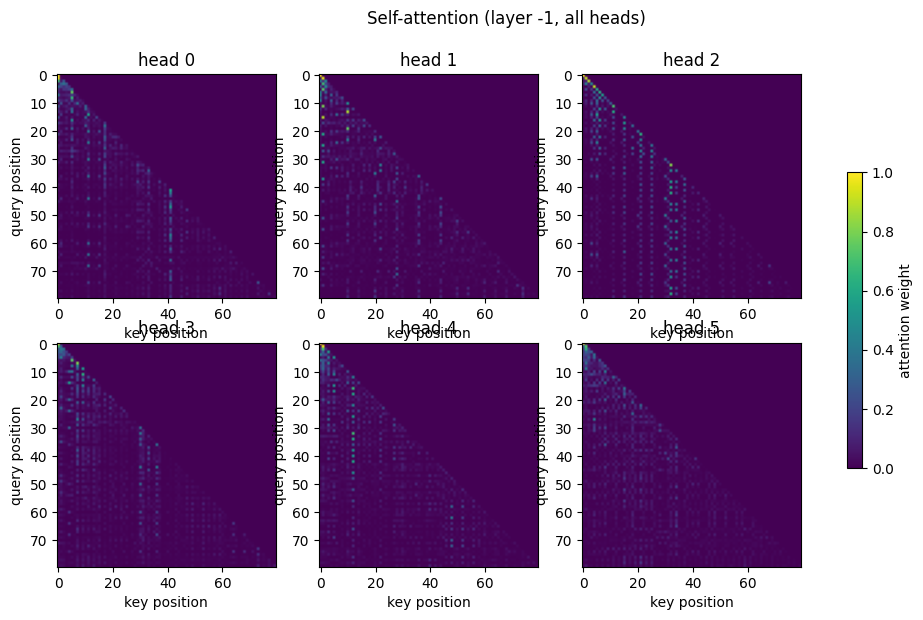

In [ ]:
import torch
import matplotlib.pyplot as plt

# put the excerpt on whatever device the model currently lives on
model_device = next(transformer.parameters()).device
excerpt = torch.tensor([val_stream[:BLOCK_SIZE]], dtype=torch.long, device=model_device)
transformer.eval()
with torch.no_grad():
    _ = transformer(excerpt)

attn  = transformer.attention_maps()
layer = -1
A_all = attn[layer][0]            # (n_head, T, T) for the chosen layer
n_head = A_all.shape[0]
W = 80                            # show the top-left WxW block

ncols = 3
nrows = (n_head + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
axes = axes.ravel()
im = None
for h in range(n_head):
    im = axes[h].imshow(A_all[h, :W, :W].cpu().numpy(), aspect="auto", origin="upper")
    axes[h].set_title(f"head {h}")
    axes[h].set_xlabel("key position"); axes[h].set_ylabel("query position")
for h in range(n_head, len(axes)):
    axes[h].axis("off")
fig.suptitle(f"Self-attention (layer {layer}, all heads)")
if im is not None:
    fig.colorbar(im, ax=axes.tolist(), label="attention weight", shrink=0.6)
plt.show()

What's great about a transformer is that we can look inside it. 

Two things to read off them:

1. **The causal mask is working.** Every map is strictly **lower-triangular**  no position attends to the future. This is a visual sanity check that our from-scratch mask is correct.
2. **Heads specialise.** Bright bands away from the diagonal indicate a head locking onto recurring structure, a fixed offset back to a previous beat, or the `GAP` token that opens each event - rather than just the immediately preceding token.

> **Observation.** Every one of the six final-layer heads is strictly lower-triangular, confirming the causal mask. The dominant pattern is a bright **first column** in all heads (strongest in heads 1 and 4), an *attention sink* on the position-0 / `BOS` token, the default a head falls back to when it has no more specific target. Beyond the sink the heads specialise: heads 0 and 3 carry a faint **near-diagonal** band (local attention to the last few sub-tokens, i.e. the `PITCH → DUR → GAP` micro-grammar within an event), while heads 2 and 5 show brighter **fixed-offset** vertical bands at an earlier key position (~30) rather than merely the previous token. The faint periodic vertical striping is consistent with the regular `GAP / PITCH / DUR / EOE` event period.

## Conclusion: neural vs. statistical

Which is better depends on the situation. Both have their uses and for each scenario:

When you care about *generalisation and long-range coherence*, transformer is your tool, since it predicts unseen continuations (lowest perplexity), holds a consistent key, and reuses motifs the way real music does. 

For matching *local* distributional statistics (pitch-class profile, note density) on a small corpus, the second-order Markov chain is hard to beat and far cheaper to train. 

On this dataset the Transformer is only a slight improvement over Markov, since there isn't enough data to feed its capacity. For the Transformer to solidly "win", **more (and augmented) training data** is needed, at which point the long-range modelling the architecture is built for should separate it clearly from both the LSTM and the Markov baselines. If not, then it depends on what you are measuring winning on (i.e. perplexity).